In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import yaml
import numpy as np
from pathlib import Path
import random
class BBoxVisualizer:
    def __init__(self, images_dir, labels_dir):
        """
        Inizializza il visualizzatore

        Args:
            images_dir: cartella con le immagini
            labels_dir: cartella con le label YOLO
        """
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)

        # Mappa dei colori per ogni classe
        self.class_names , self.class_colors = self._load_classes_from_yaml()

    def _load_classes_from_yaml(self):
        """Carica i nomi delle classi dal file dataset.yaml"""
        import yaml
        from pathlib import Path

        yaml_path = Path("dataset_output/dataset.yaml")
        class_names = {}
        class_colors = {}

        if not yaml_path.exists():
            print(f"⚠️  File {yaml_path} non trovato, uso classi di default")
            class_names = {0: 'Class_0', 1: 'Class_1', 2: 'Class_2'}
            class_colors = {0: 'red', 1: 'blue', 2: 'green'}
            return class_names, class_colors

        try:
            with open(yaml_path, 'r', encoding='utf-8') as f:
                content = f.read()

            import re
            import ast

            # Cerca il formato lista: names: ['archer', 'barbarian', ...]
            list_match = re.search(r'names:\s*(\[.*?\])', content, re.DOTALL)

            if list_match:
                # Formato lista
                list_str = list_match.group(1)
                names_list = ast.literal_eval(list_str)

                # Crea dizionario {id: nome}
                class_names = {idx: name for idx, name in enumerate(names_list)}

            else:
                # Fallback: cerca formato dizionario vecchio
                dict_match = re.search(r'names:\s*(\{[^}]+\})', content)

                if dict_match:
                    dict_str = dict_match.group(1)
                    names_dict = ast.literal_eval(dict_str)
                    # Inverti: da {nome: id} a {id: nome}
                    class_names = {v: k for k, v in names_dict.items()}
                else:
                    raise ValueError("Formato names non riconosciuto")

            if not class_names:
                raise ValueError("Nessuna classe trovata nel file YAML")

            # Genera colori automaticamente
            colors = [
                'red', 'blue', 'green', 'orange', 'purple', 'cyan',
                'magenta', 'yellow', 'lime', 'pink', 'brown', 'gray',
                'olive', 'navy', 'teal', 'maroon', 'coral', 'gold',
                'salmon', 'khaki', 'violet', 'indigo', 'turquoise'
            ]

            for class_id in class_names.keys():
                class_colors[class_id] = colors[class_id % len(colors)]

            print(f"✓ Caricate {len(class_names)} classi da {yaml_path.name}")
            for cid, cname in sorted(class_names.items())[:10]:  # mostra prime 10
                print(f"   {cid}: {cname}")
            if len(class_names) > 10:
                print(f"   ... e altre {len(class_names) - 10} classi")

        except Exception as e:
            print(f"⚠️  Errore nel leggere {yaml_path}: {e}")
            print("   Uso classi di default")
            class_names = {0: 'Class_0', 1: 'Class_1', 2: 'Class_2'}
            class_colors = {0: 'red', 1: 'blue', 2: 'green'}

        return class_names, class_colors

    def yolo_to_bbox(self, x_center, y_center, width, height, img_width, img_height):
        """
        Converte coordinate YOLO in coordinate bbox standard

        Returns:
            (x_min, y_min, width, height) in pixel
        """
        x_center_px = x_center * img_width
        y_center_px = y_center * img_height
        width_px = width * img_width
        height_px = height * img_height

        x_min = x_center_px - width_px / 2
        y_min = y_center_px - height_px / 2

        return x_min, y_min, width_px, height_px

    def load_annotations(self, label_path):
        """Carica le annotazioni da un file YOLO"""
        annotations = []

        if not label_path.exists():
            return annotations

        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])
                    annotations.append((class_id, x_center, y_center, width, height))

        return annotations

    def visualize_image(self, image_path, ax=None):
        """
        Visualizza una singola immagine con le sue bounding box

        Args:
            image_path: percorso dell'immagine
            ax: matplotlib axis (opzionale)
        """
        if ax is None:
            fig, ax = plt.subplots(1, figsize=(12, 8))

        # Carica immagine
        img = Image.open(image_path)
        img_width, img_height = img.size

        # Mostra immagine
        ax.imshow(img)

        # Trova il file label corrispondente
        image_name = image_path.stem
        label_path = self.labels_dir / f"{image_name}.txt"

        # Carica e disegna le annotazioni
        annotations = self.load_annotations(label_path)

        for class_id, x_center, y_center, width, height in annotations:
            # Converti in coordinate pixel
            x_min, y_min, bbox_width, bbox_height = self.yolo_to_bbox(
                x_center, y_center, width, height, img_width, img_height
            )

            # Crea il rettangolo
            color = self.class_colors.get(class_id, 'yellow')
            rect = patches.Rectangle(
                (x_min, y_min), bbox_width, bbox_height,
                linewidth=3, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)

            # Aggiungi label
            label = self.class_names.get(class_id, f'Class {class_id}')
            ax.text(
                x_min, y_min - 5,
                label,
                color='white',
                fontsize=12,
                fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.8, edgecolor='none', pad=3)
            )

        ax.axis('off')
        ax.set_title(f"{image_path.name} - {len(annotations)} oggetti", fontsize=14, fontweight='bold')

        return ax

    def visualize_random_samples(self, num_samples=6):
        """Visualizza campioni casuali dal dataset"""
        # DEBUG: Verifica percorso
        print(f"\n🔍 Debug - Cercando immagini in: {self.images_dir.absolute()}")
        print(f"   Cartella esiste? {self.images_dir.exists()}")

        if not self.images_dir.exists():
            print(f"❌ La cartella {self.images_dir} NON ESISTE!")
            print(f"   Percorso assoluto: {self.images_dir.absolute()}")
            return

        # Trova tutte le immagini
        jpg_images = list(self.images_dir.glob("*.jpg"))
        png_images = list(self.images_dir.glob("*.png"))
        images = jpg_images + png_images

        print(f"   Trovate {len(jpg_images)} immagini .jpg")
        print(f"   Trovate {len(png_images)} immagini .png")
        print(f"   Totale: {len(images)} immagini\n")

        if len(images) == 0:
            print(f"❌ Nessuna immagine trovata in {self.images_dir}")
            print(f"   Contenuto della cartella:")
            all_files = list(self.images_dir.glob("*"))
            if len(all_files) == 0:
                print(f"   La cartella è VUOTA")
            else:
                for f in all_files[:10]:  # Mostra max 10 file
                    print(f"     - {f.name}")
            return

        # Seleziona campioni casuali
        samples = random.sample(images, min(num_samples, len(images)))

        # Calcola layout griglia
        cols = 3
        rows = (len(samples) + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
        fig.suptitle('Verifica Bounding Box Dataset', fontsize=16, fontweight='bold')

        # Appiattisci axes per iterazione facile
        if rows == 1 and cols == 1:
            axes = [axes]
        elif rows == 1 or cols == 1:
            axes = axes.flatten()
        else:
            axes = axes.flatten()

        for idx, img_path in enumerate(samples):
            self.visualize_image(img_path, axes[idx])

        # Nascondi assi inutilizzati
        for idx in range(len(samples), len(axes)):
            axes[idx].axis('off')

        plt.tight_layout()
        plt.show()

    def visualize_specific_image(self, image_name):
        """Visualizza una specifica immagine per nome"""
        image_path = self.images_dir / image_name

        if not image_path.exists():
            print(f"❌ Immagine non trovata: {image_path}")
            return

        fig, ax = plt.subplots(1, figsize=(14, 10))
        self.visualize_image(image_path, ax)
        plt.tight_layout()
        plt.show()

    def check_dataset_stats(self):
        """Mostra statistiche sul dataset"""
        images = list(self.images_dir.glob("*.jpg")) + list(self.images_dir.glob("*.png"))
        labels = list(self.labels_dir.glob("*.txt"))

        print("\n" + "="*50)
        print("        STATISTICHE DATASET")
        print("="*50)
        print(f"Totale immagini: {len(images)}")
        print(f"Totale file label: {len(labels)}")
        print()

        # Conta oggetti per classe
        class_counts = {0: 0, 1: 0, 2: 0}
        total_objects = 0
        images_with_objects = 0

        for label_path in labels:
            annotations = self.load_annotations(label_path)
            if len(annotations) > 0:
                images_with_objects += 1
            total_objects += len(annotations)

            for class_id, _, _, _, _ in annotations:
                if class_id in class_counts:
                    class_counts[class_id] += 1

        print(f"Immagini con oggetti: {images_with_objects}")
        print(f"Totale oggetti annotati: {total_objects}")
        if images_with_objects > 0:
            print(f"Media oggetti per immagine: {total_objects / images_with_objects:.2f}")
        print()
        print("Distribuzione per classe:")
        print("-" * 50)
        for class_id, count in class_counts.items():
            class_name = self.class_names.get(class_id, f'Class {class_id}')
            percentage = (count / total_objects * 100) if total_objects > 0 else 0
            color = self.class_colors.get(class_id, 'yellow')
            bar = "█" * int(percentage / 2)
            print(f"  {class_name:15} : {count:4} ({percentage:5.1f}%) {bar}")
        print("="*50 + "\n")


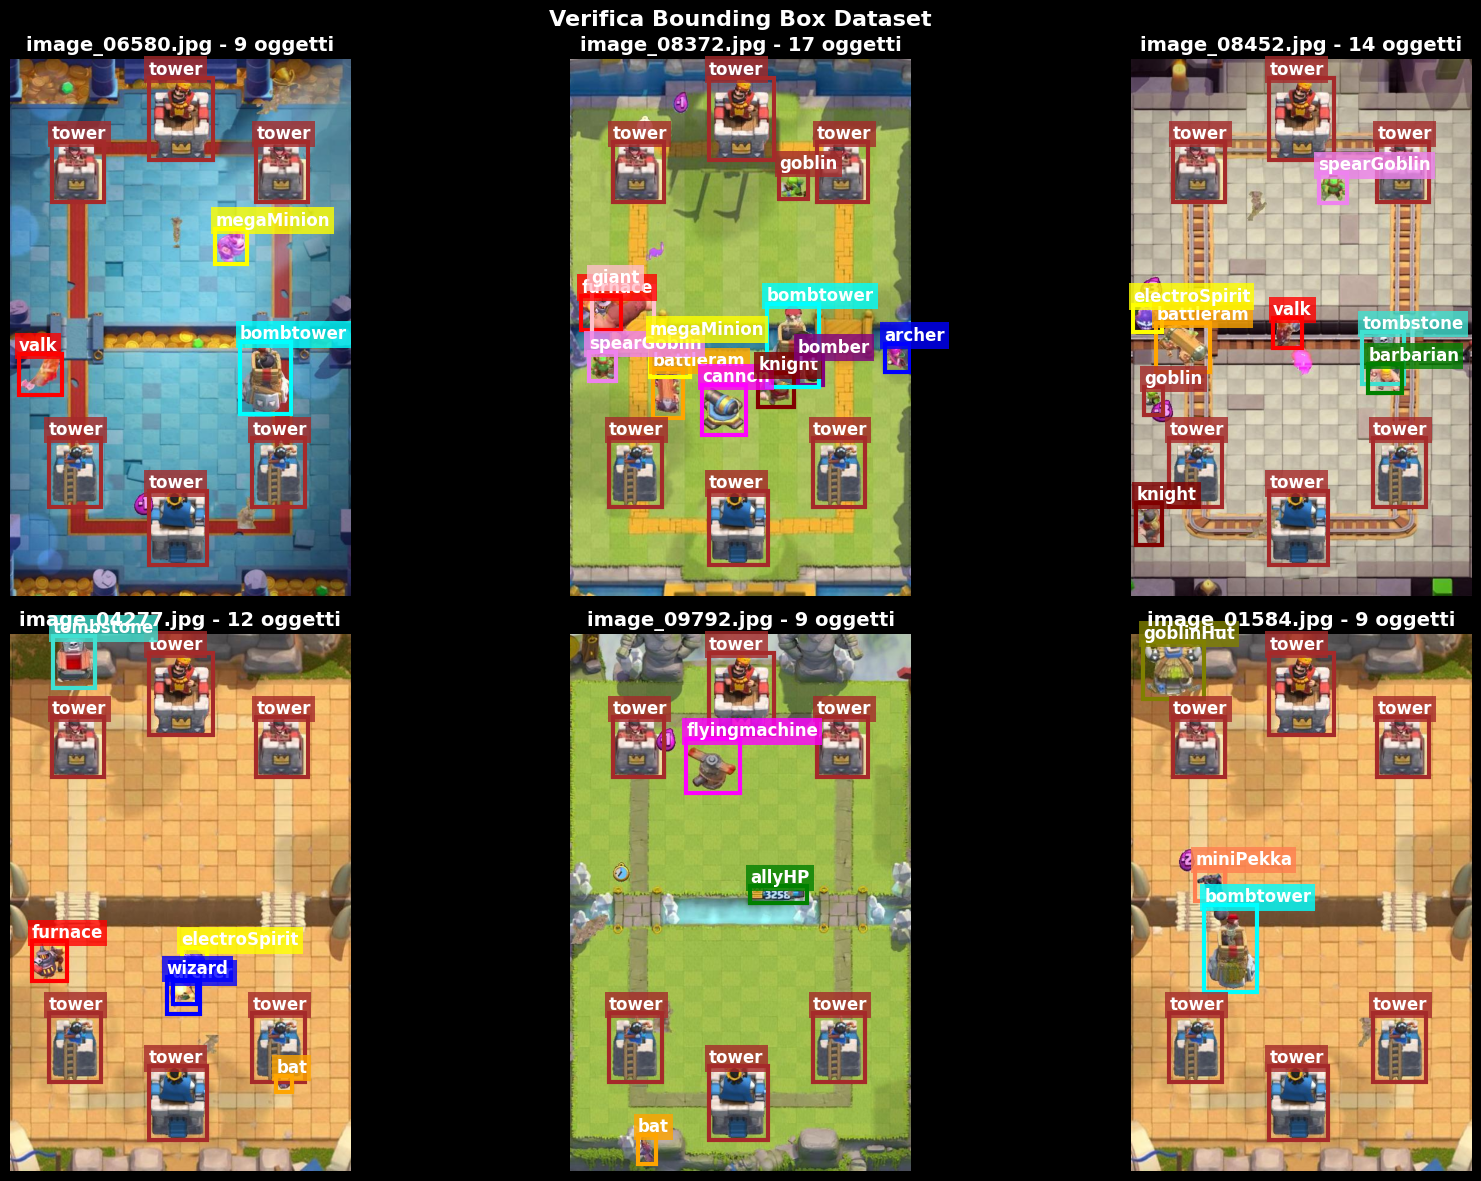

In [2]:
if __name__ == "__main__":
    # MODIFICA QUESTI PERCORSI
    IMAGES_DIR = "dataset_output/images"
    LABELS_DIR = "dataset_output/labels"

    print("\n🔍 VISUALIZZATORE BOUNDING BOX YOLO")
    print("="*50)

    # Crea il visualizzatore
    visualizer = BBoxVisualizer(IMAGES_DIR, LABELS_DIR)

    # Mostra statistiche
    visualizer.check_dataset_stats()

    # Visualizza 6 immagini casuali
    print("📊 Visualizzazione campioni casuali...")
    visualizer.visualize_random_samples(num_samples=6)